# Early Dark Energy Linear Theory & Halo-Scale Bridge

Interactive research notebook demonstrating:
1. Loading the frozen `LINEAR_THEORY_V1` Parquet dataset
2. Validating cosmic background energy fractions and Hubble elevation
3. Inspecting the subhorizon Mészáros growth suppression and scale-dependent $\epsilon_D(k, z)$
4. Evaluating halo mass variance $\sigma(M, z)$ and peak height $\nu(M, z)$

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_dir = Path("../artifacts/processed/LINEAR_THEORY_V1").resolve()
print("Loading dataset from:", data_dir)

df_bg = pd.read_parquet(data_dir / "background_history.parquet")
df_grid = pd.read_parquet(data_dir / "matter_power_grid.parquet")
df_growth = pd.read_parquet(data_dir / "growth_diagnostics.parquet")
df_desc = pd.read_parquet(data_dir / "halo_scale_descriptors.parquet")

print("Background rows:", len(df_bg))
print("Power grid rows:", len(df_grid))
print("Growth rows:", len(df_growth))
print("Descriptor rows:", len(df_desc))

Loading dataset from: /Users/bbird/Downloads/Research/Dark_Matter_Bird/artifacts/processed/LINEAR_THEORY_V1
Background rows: 100000
Power grid rows: 1584
Growth rows: 1584
Descriptor rows: 300


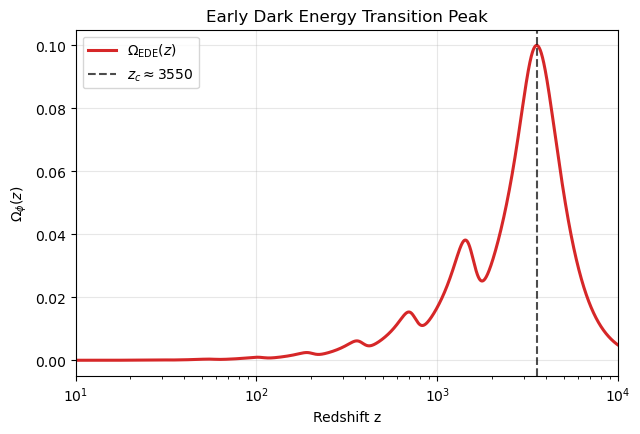

In [2]:
# 1. Plot Background EDE Fraction
plt.figure(figsize=(7, 4.5))
plt.semilogx(
    df_bg["redshift"], df_bg["omega_phi"], color="#d62728", lw=2.2, label=r"$\Omega_{\rm EDE}(z)$"
)
plt.axvline(3548, color="black", ls="--", alpha=0.7, label=r"$z_c \approx 3550$")
plt.xlabel("Redshift z")
plt.ylabel(r"$\Omega_\phi(z)$")
plt.title("Early Dark Energy Transition Peak")
plt.xlim(1e1, 1e4)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

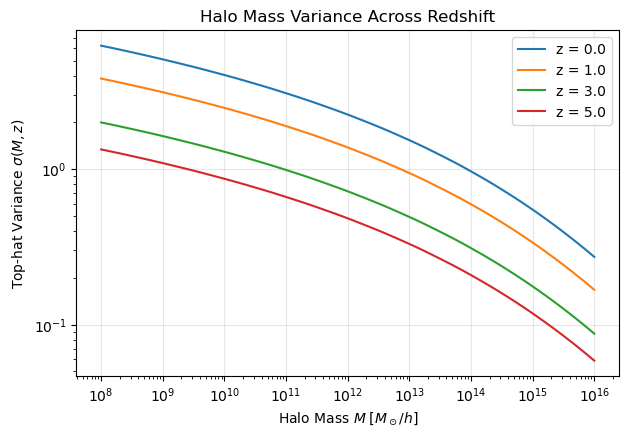

In [3]:
# 2. Plot Halo Mass Variance sigma(M, z)
plt.figure(figsize=(7, 4.5))
for z_val in [0.0, 1.0, 3.0, 5.0]:
    sub = df_desc[df_desc["redshift"] == z_val]
    plt.loglog(sub["mass_Msun_h"], sub["sigma"], label=f"z = {z_val}")

plt.xlabel(r"Halo Mass $M\;[M_\odot / h]$")
plt.ylabel(r"Top-hat Variance $\sigma(M, z)$")
plt.title("Halo Mass Variance Across Redshift")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()